In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")


from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    cross_val_predict,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

RANDOM_SEED = 42

## EDA

In [2]:
df = pd.read_csv('historical_data.csv')

df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [3]:
print("Antal rader:", df.shape[0])
print("Antal kolumner:", df.shape[1])

print("\nDatasetets datatyper:")
print("------------------------------")
print(df.dtypes)

Antal rader: 12000
Antal kolumner: 18

Datasetets datatyper:
------------------------------
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object


In [4]:
print("\nSaknade värden per kolumn:")
print("------------------------------")
print(df.isna().sum())


Saknade värden per kolumn:
------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


In [5]:
df = df.drop(columns=['id'])

df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00
urgency_words,12000.0,0.099083,0.298786,0.00,0.000,0.000,0.000,1.00


In [6]:
print("Target-fördelning:")
print(df["is_suspicious"].value_counts())

print("\nProcentuell fördelning:")
print(df["is_suspicious"].value_counts(normalize=True) * 100)

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Procentuell fördelning:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


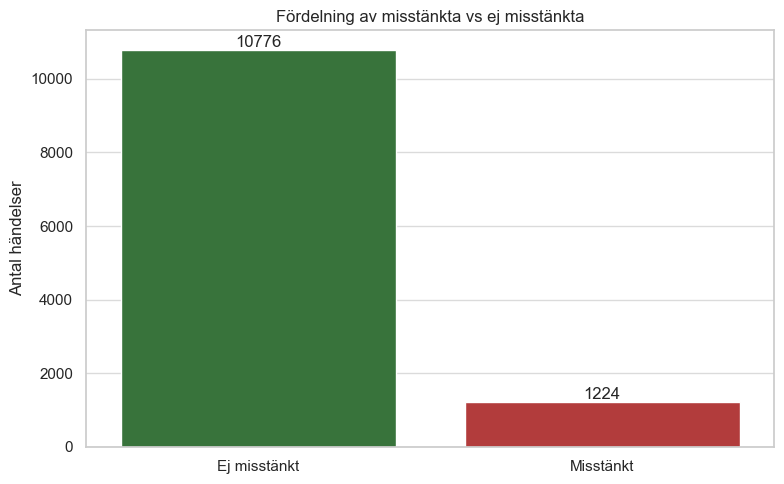

In [7]:
counts = df["is_suspicious"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = sns.countplot(x="is_suspicious", hue="is_suspicious", data=df, palette=["#2E7D32", "#C62828"], legend=False)
plt.title("Fördelning av misstänkta vs ej misstänkta")
plt.xlabel("")
plt.ylabel("Antal händelser")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(True, axis="y", alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=np.number)

correlations = numeric_cols.corr()["is_suspicious"].sort_values(ascending=False)

top_corr = correlations.drop("is_suspicious")

top_corr = top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
top_5 = top_corr.head(5)

print("Korrelation med is_suspicious:")
print("----------------------------------")
print(top_5)

Korrelation med is_suspicious:
----------------------------------
contains_off_platform    0.141828
prev_reports_30d         0.130920
account_age_days        -0.103146
verification_level      -0.100409
urgency_words            0.087295
Name: is_suspicious, dtype: float64


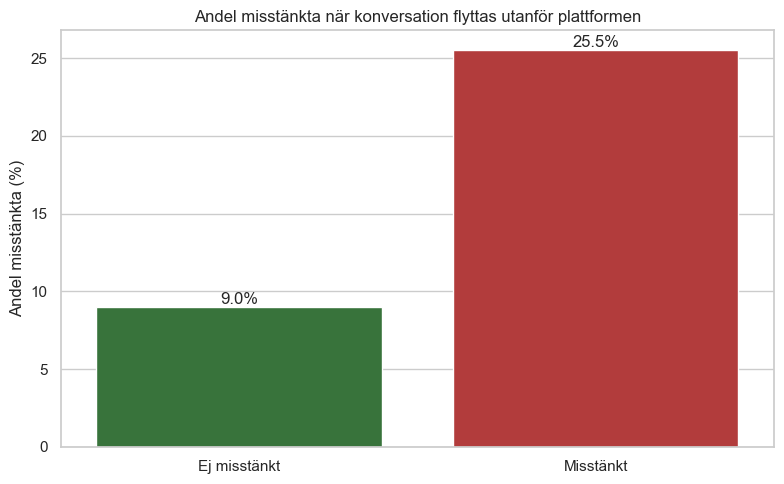

In [9]:
cross_tab = pd.crosstab(
    df["contains_off_platform"],
    df["is_suspicious"],
    normalize="index"
) * 100

risk_percent = cross_tab[1]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=risk_percent.index, hue=risk_percent.index,
    y=risk_percent.values, palette=["#2E7D32", "#C62828"], legend=False
)

plt.title("Andel misstänkta när konversation flyttas utanför plattformen")
plt.xlabel("")
plt.ylabel("Andel misstänkta (%)")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for i, v in enumerate(risk_percent.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Insikter
- Modellen/policyn ska fokusera på en minoritet med hög risk då datasetet är obalanserat.  
- Risken är mycket högre när användaren försöker flytta konversationen utanför plattformen (25.5%). Detta är en tydlig signal som kan användas för prioritering. 

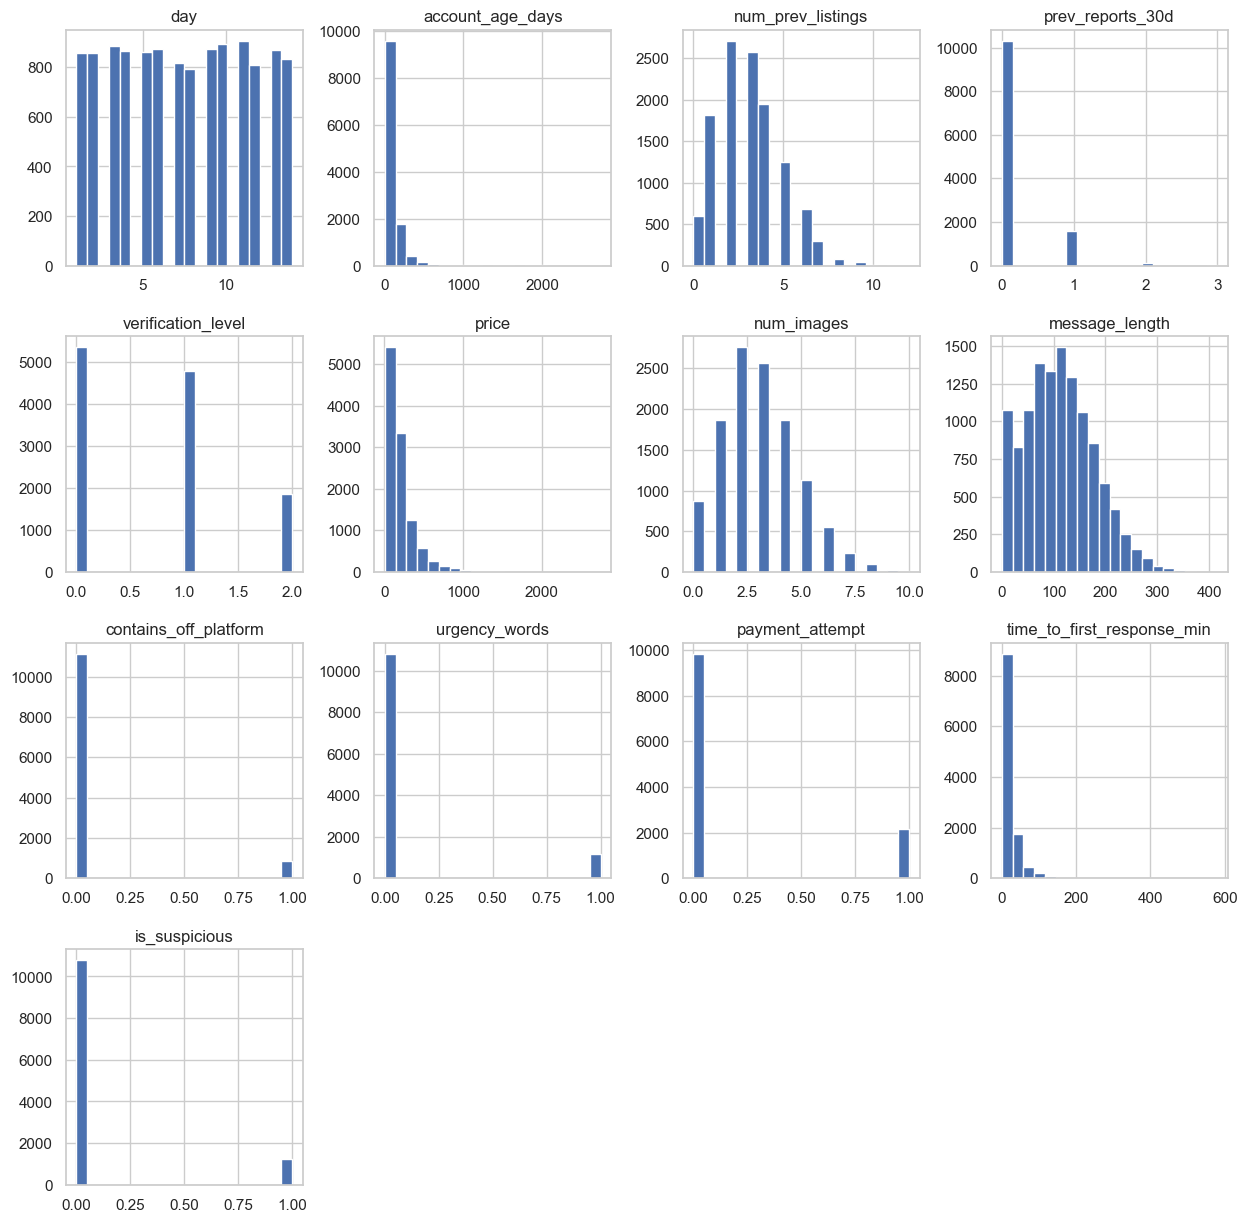

In [10]:
df.hist(figsize=(15,15), bins=20)
plt.show()

Split data

In [11]:

X = df.copy()

num_cols = ['day',
            'account_age_days',
            'num_prev_listings',
            'prev_reports_30d',
            'verification_level',
            'price', 
            'num_images',
            'message_length',
            'contains_off_platform',
            'urgency_words',
            'payment_attempt',
            'time_to_first_response_min',
            "avg_listings_per_day",
            "report_ratio"
            ]

cat_cols = ['event_type', 'category', 'region', 'device']

# skapede features för se om det gjorde någon skillnad
#X["report_ratio"] = df["prev_reports_30d"] / (df["num_prev_listings"] + 1)
#X["avg_listings_per_day"] = df["num_prev_listings"] / (df["account_age_days"] + 1)


drop_columns = [
    "is_suspicious"
    ]


X = X.drop(columns= drop_columns)
y = df['is_suspicious'].copy()

# lägger alla använda features i en lista för senare använding i pipeline

columns_used = [c for c in X.columns if c not in drop_columns]



In [12]:


# Använd för K-fold eller cross validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify=y
)



Pipeline

In [13]:

selected_num_cols = [x for x in columns_used if x in num_cols]
selected_cat_cols = [x for x in columns_used if x in cat_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



preprocess = ColumnTransformer([
    ("num", num_pipe, selected_num_cols),
    ("cat", cat_pipe, selected_cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])



In [14]:
log_reg = LogisticRegression(max_iter=200, class_weight="balanced")
rf = RandomForestClassifier(max_depth=5, random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced_subsample")
dt = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")
gb = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_dummy = DummyClassifier(strategy="stratified")

## Cross Validation

In [15]:
model_lr = make_model(log_reg)
model_rf = make_model(rf)
model_dt = make_model(dt)
model_gb = make_model(gb)
model_dummy = make_model(model_dummy)

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "average_precision"

In [17]:
models = {
    "Dummy": model_dummy,
    "LogisticRegression": model_lr,
    "RandomForest": model_rf,
    "DecisionTree": model_dt,
    "GradientBoosting": model_gb
}


baseline_rows = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

,model,mean,std
4,GradientBoosting,0.287606,0.025802
1,LogisticRegression,0.281588,0.026315
2,RandomForest,0.274969,0.016420
3,DecisionTree,0.115741,0.006164
0,Dummy,0.102785,0.001838


## Top två modeller

In [18]:
top2_models = baseline_table["model"].head(2).tolist()
print("top-2 models", top2_models)

best_model = models[top2_models[0]]
second_best_model = models[top2_models[1]]


top-2 models ['GradientBoosting', 'LogisticRegression']


## Hyperparametrar för alla modeller

In [31]:
param_lr = {
    "model__C": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["liblinear"]
}

param_rf = {
    "model__n_estimators": [500, 700],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [6, 8, 10],
    "model__max_features": ["sqrt", "log2"]
}


param_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [3, 4, 5],
    "model__subsample": [0.8,0.9],

}

param_dt = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 4],
}

dict_models_params = {
    "LogisticRegression": [model_lr, param_lr],
    "RandomForest": [model_rf, param_rf],
    "DecisionTree": [model_dt, param_dt],
    "GradientBoosting": [model_gb, param_gb]
}

## Tränar de två bästa modellerna

In [32]:
first = dict_models_params[top2_models[0]]
second = dict_models_params[top2_models[1]]


grid_1 = GridSearchCV(
    estimator=first[0],
    param_grid=first[1],
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
    )

grid_1.fit(X_train, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05], 'model__max_depth': [2, 3], 'model__min_samples_leaf': [3, 4, ...], 'model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

In [33]:

grid_1.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 2,
 'model__min_samples_leaf': 4,
 'model__n_estimators': 200,
 'model__subsample': 0.9}

In [22]:
grid_2 = GridSearchCV(
    estimator=second[0],
    param_grid=second[1],
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
)

grid_2.fit(X_train, y_train)



Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\simon\Desktop\Marketplace\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...x_iter=200))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.0001, 0.001, ...], 'model__penalty': ['l2'], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [34]:
grid_2.best_params_

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

## Vem är vinnaren?

In [23]:

print(grid_1.best_score_)
print(grid_2.best_score_)

if grid_1.best_score_ > grid_2.best_score_:
    print("The winner is:", top2_models[0])
else:
    print("´The winner is:", top2_models[1])

best_model = grid_1 if grid_1.best_score_ > grid_2.best_score_ else grid_2


0.30687219737396576
0.2815535920802275
The winner is: GradientBoosting


## Feature importance

Här visas vilka variabler som modellen anser vara viktigast för att göra sina prediktioner. 
Feature importance visar hur mycket varje feature bidrar till modellens beslut. 
Högre värde betyder att variabeln har större påverkan på modellens prediktioner.## Feature importance

In [24]:

model_step = best_model.best_estimator_.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_model.best_estimator_.named_steps["preprocess"].get_feature_names_out()

    importances = model_step.feature_importances_

    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print(fi)

else:
    print("This model does not support feature_importances_.")


num__account_age_days              0.346940
num__contains_off_platform         0.161169
num__prev_reports_30d              0.160238
num__verification_level            0.098063
num__urgency_words                 0.060356
num__time_to_first_response_min    0.051445
num__payment_attempt               0.033365
num__price                         0.026739
num__message_length                0.019819
num__day                           0.015527
num__num_images                    0.014495
num__num_prev_listings             0.004141
cat__region_urban                  0.002455
cat__event_type_message_send       0.001814
cat__region_rural                  0.001000
cat__category_phones               0.000933
cat__device_web                    0.000751
cat__device_ios                    0.000738
cat__event_type_ad_post            0.000010
cat__category_fashion              0.000000
cat__category_electronics          0.000000
cat__category_bikes                0.000000
cat__category_furniture         

## top 5 feature importance

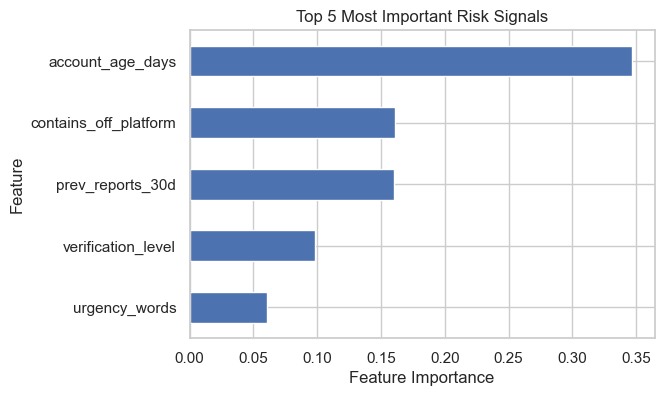

In [25]:
top5 = fi.head(5)
top5.index = top5.index.str.replace("num__", "")

plt.figure(figsize=(6,4))
top5.sort_values().plot(kind="barh")

plt.title("Top 5 Most Important Risk Signals")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Threshold

## Top n%

Här testar vi olika procent av datan för de observationer som modellen tycker har högst sannolikhet att vara skam. 
Tanken är att ett företag ofta bara kan granska ett begränsat antal fall, så man prioriterar de mest riskfyllda.

För varje nivå av X räknar vi ut precision och recall för att se hur valet av procent påverkar hur många skamfall 
vi hittar och hur många falska larm modellen ger.

In [26]:
probs = best_model.predict_proba(X_test)[:,1]

top = []
for p in [0.01, 0.05, 0.10, 0.20]:
    top_n = int(len(probs) * p)
    idx = np.argsort(probs)[::-1][:top_n]
    y_top = y_test.iloc[idx]

    precision = y_top.mean()
    recall = y_top.sum() / y_test.sum()

    top.append({"Procent": f"Top {int(p*100)}%", "Precision": round(precision, 3), "Recall": round(recall, 3)})

top_table = pd.DataFrame(top)
top_table

,Procent,Precision,Recall
0,Top 1%,0.583,0.057
1,Top 5%,0.400,0.196
2,Top 10%,0.367,0.359
3,Top 20%,0.277,0.543


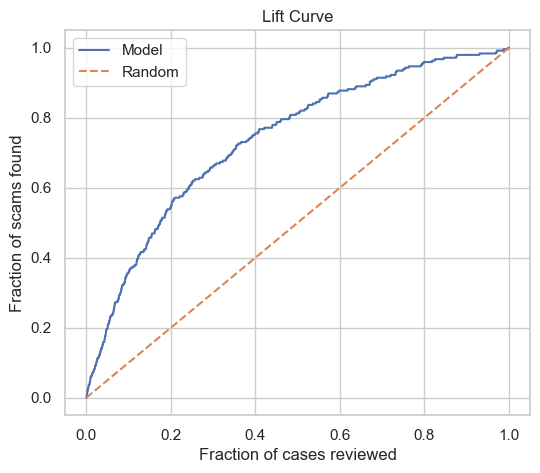

In [27]:
lift_df = pd.DataFrame({
    "y_true": y_test,
    "prob": probs
})

lift_df = lift_df.sort_values("prob", ascending=False)


lift_df["cum_cases"] = np.arange(1, len(lift_df)+1)
lift_df["cum_scams"] = lift_df["y_true"].cumsum()

lift_df["recall"] = lift_df["cum_scams"] / lift_df["y_true"].sum()
lift_df["percent_data"] = lift_df["cum_cases"] / len(lift_df)

# plot lift curve
plt.figure(figsize=(6,5))
plt.plot(lift_df["percent_data"], lift_df["recall"], label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("Fraction of cases reviewed")
plt.ylabel("Fraction of scams found")
plt.title("Lift Curve")
plt.legend()
plt.show()

## Precision och Recall vs Threshold

Här visas hur precision och recall förändras vid olika tröskelvärden. Genom att justera threshold kan man styra balansen mellan att få hög precision och att hitta fler skamfall (hög recall). Grafen hjälper till att välja ett threshold som passar verksamhetens behov.

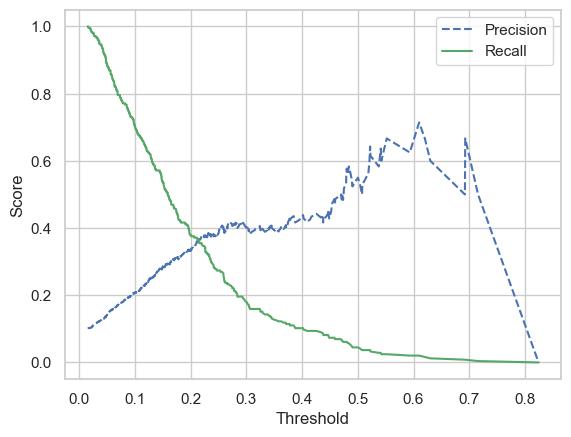

In [28]:

precisions, recalls, thresholds  = precision_recall_curve(y_test, probs)


def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

## Val av threshold med F1-score

För att hitta ett lämpligt tröskelvärde beräknas F1-score för varje möjligt threshold från precision-recall-kurvan. 
Den threshold som ger högst F1-score väljs eftersom den ger bäst balans mellan precision och recall. 
I detta fall ligger den bästa threshold runt 0.15.
 - alla i top-n behandlas som flaggade positiva
 - precision = andel verkliga scams bland flaggade
 - recall = andel av alla scams som fångas

In [29]:
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

p = precisions[:-1]
r = recalls[:-1]

f1 = np.zeros_like(p)
mask = (p + r) != 0
f1[mask] = 2 * p[mask] * r[mask] / (p[mask] + r[mask])

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {f1[best_idx]:.2f}")

Best threshold: 0.15
Best F1: 0.38


## confusion matrix 

Confusion matrix för bästa treshholden som gav högst f1 score

              precision    recall  f1-score   support

           0       0.94      0.84      0.89      2155
           1       0.28      0.56      0.37       245

    accuracy                           0.81      2400
   macro avg       0.61      0.70      0.63      2400
weighted avg       0.88      0.81      0.83      2400



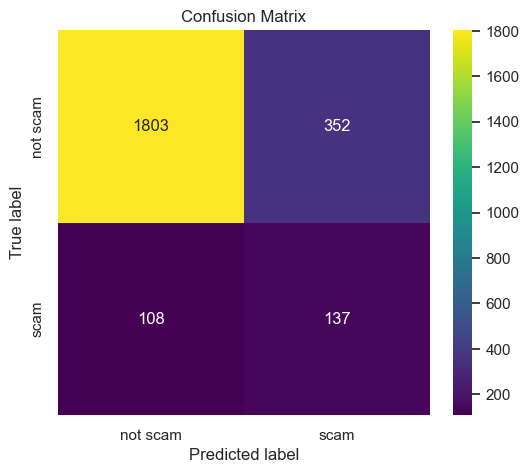

In [30]:

pred = (probs > best_threshold).astype(int)


print(classification_report(y_test, pred))


cm = confusion_matrix(y_test, pred)


plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['not scam', 'scam'],
    yticklabels=['not scam', 'scam']
)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')

plt.show()